In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#installing the libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [3]:
#load our dataset
df = pd.read_csv('../data/gas_price_2526.csv')

#display basic information
print(df.info())
#display the first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         500 non-null    object 
 1   daily price  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


,date,daily price
0,19/01/2025,39.85
1,20/01/2025,37.21
2,21/01/2025,37.33
3,22/01/2025,37.85
4,23/01/2025,35.70


In [4]:
# date is object(means string) convert into date and time object
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y') #(dd/mm/yyyy)

#set date column as index(TS)
df.set_index('date', inplace=True)

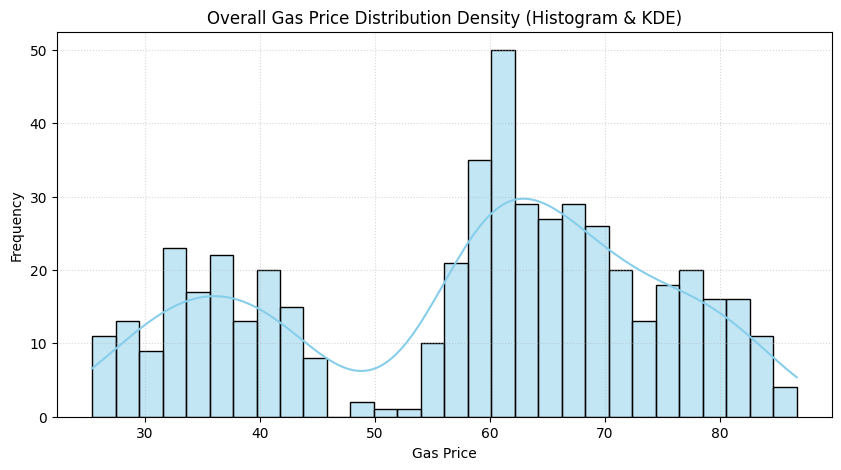

In [5]:
# Plotting overall density spread of the target asset
plt.figure(figsize=(10, 5))
sns.histplot(df['daily price'], kde=True, color='skyblue', bins=30)
plt.title('Overall Gas Price Distribution Density (Histogram & KDE)')
plt.xlabel('Gas Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

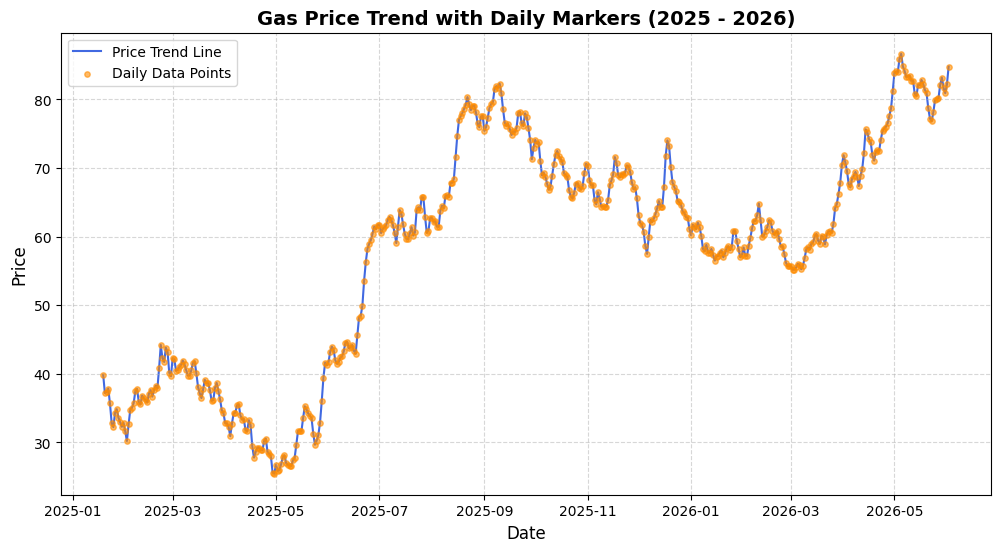

In [6]:
#line and scatter plot
plt.figure(figsize=(12, 6))

#continuous line
plt.plot(df.index, df['daily price'], color='royalblue', linewidth=1.5, label='Price Trend Line', zorder=1)
#s => size of dot, alpha=>transparency, =
plt.scatter(df.index, df['daily price'], color='darkorange', s=15, alpha=0.6, label='Daily Data Points', zorder=2)

plt.title('Gas Price Trend with Daily Markers (2025 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

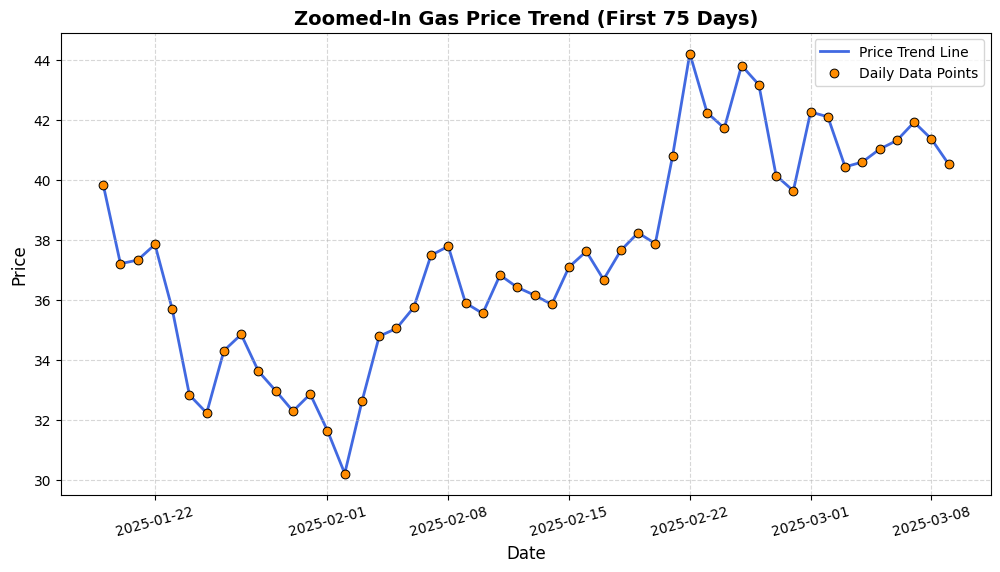

In [7]:
#too clumsy with all 500 pts, zoom for 10% 50 datapoints (first 50 data points)
df_zoom = df.iloc[0:50]

plt.figure(figsize=(12, 6))

#line for 50 pts
plt.plot(df_zoom.index, df_zoom['daily price'], color='royalblue', linewidth=2, label='Price Trend Line', zorder=1)

#add dots(scatter points/data points for the same timeframe)
plt.scatter(df_zoom.index, df_zoom['daily price'], color='darkorange', s=40, edgecolors='black', linewidth=0.7, label='Daily Data Points', zorder=2)

plt.title('Zoomed-In Gas Price Trend (First 75 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=15)
plt.show()

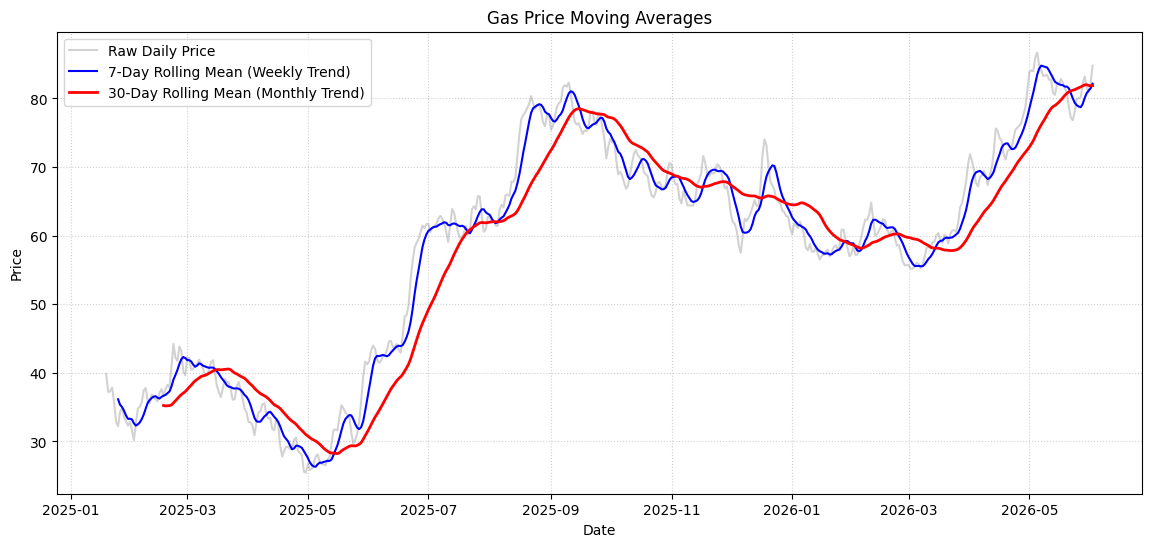

In [8]:
#short and medium term rolling trends
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['daily price'], label='Raw Daily Price', color='gray', alpha=0.35)
plt.plot(df.index, df['daily price'].rolling(window=7).mean(), label='7-Day Rolling Mean (Weekly Trend)', color='blue', lw=1.5)
plt.plot(df.index, df['daily price'].rolling(window=30).mean(), label='30-Day Rolling Mean (Monthly Trend)', color='red', lw=2)
plt.title('Gas Price Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

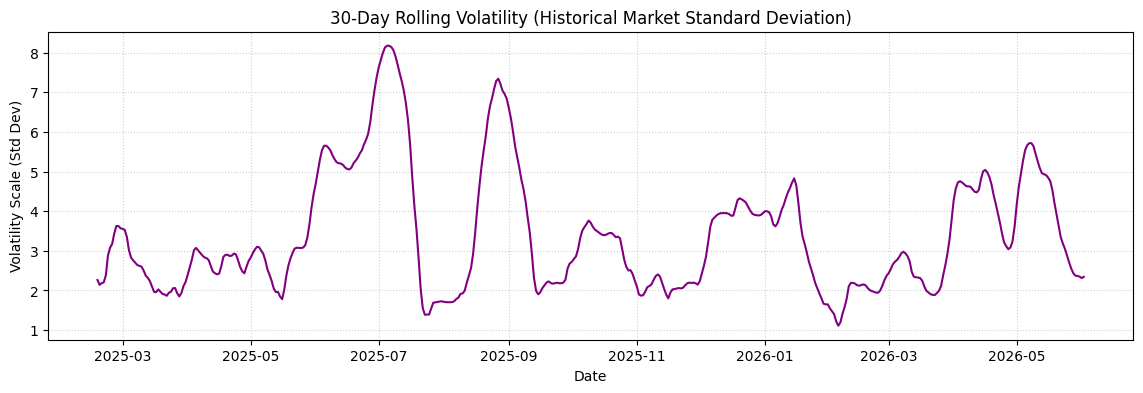

In [9]:
#Standard deviation check
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['daily price'].rolling(window=30).std(), color='purple', lw=1.5)
plt.title('30-Day Rolling Volatility (Historical Market Standard Deviation)')
plt.xlabel('Date')
plt.ylabel('Volatility Scale (Std Dev)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

C:\Users\sagal\AppData\Local\Temp\ipykernel_34108\3016882680.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_seasonal, x='Month_Name', y='daily price', palette='viridis')


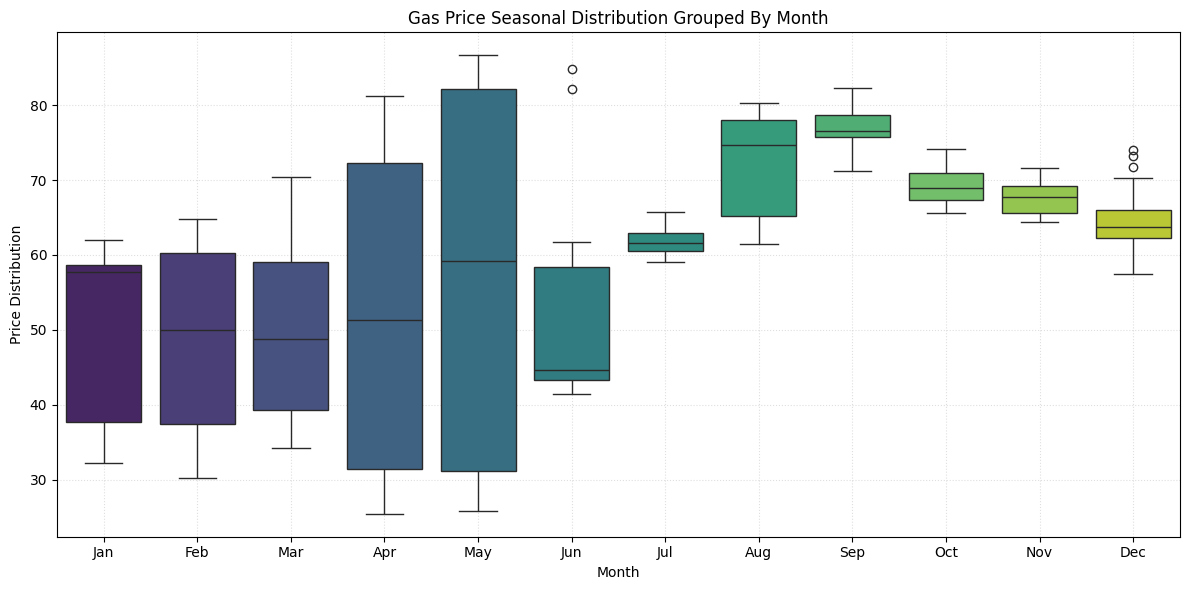

In [10]:
#seasonal shifts analysis
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_seasonal = df.copy()
df_seasonal['Month_Name'] = df_seasonal.index.strftime('%b')
df_seasonal['Month_Name'] = pd.Categorical(df_seasonal['Month_Name'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_seasonal, x='Month_Name', y='daily price', palette='viridis')
plt.title('Gas Price Seasonal Distribution Grouped By Month')
plt.xlabel('Month')
plt.ylabel('Price Distribution')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

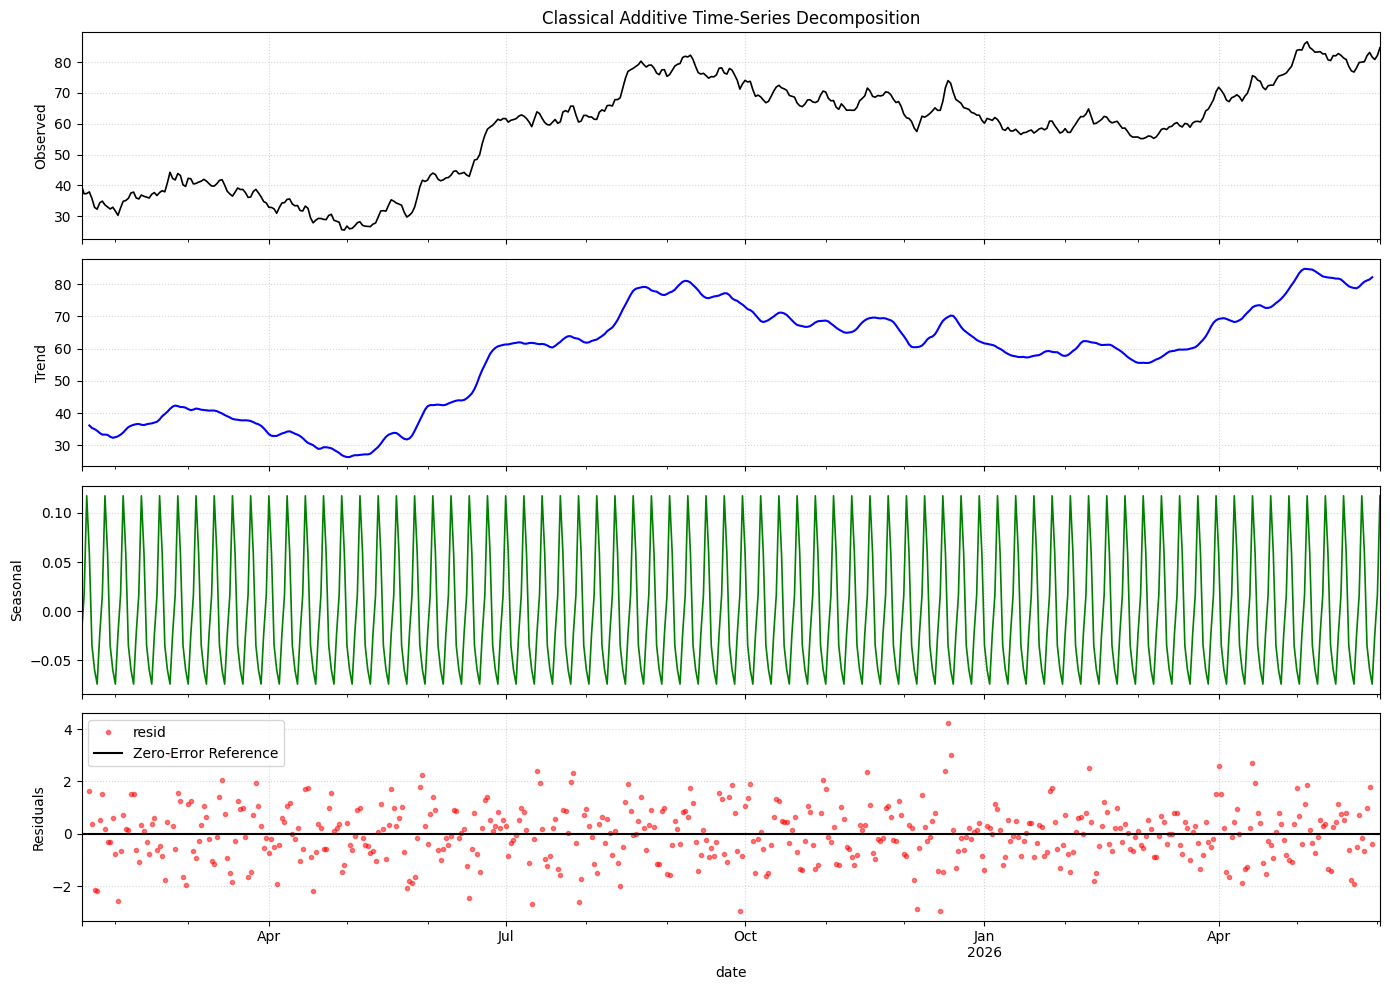

In [11]:
#Time series decomposition
decomposition = seasonal_decompose(df['daily price'], model='additive', period=7)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

#observed plot
decomposition.observed.plot(ax=ax1, color='black', lw=1.2)
ax1.set_ylabel('Observed')
ax1.set_title('Classical Additive Time-Series Decomposition')
ax1.grid(True, linestyle=':', alpha=0.5)

#trend plot
decomposition.trend.plot(ax=ax2, color='blue', lw=1.5)
ax2.set_ylabel('Trend')
ax2.grid(True, linestyle=':', alpha=0.5)

#seasonal plot
decomposition.seasonal.plot(ax=ax3, color='green', lw=1.2)
ax3.set_ylabel('Seasonal')
ax3.grid(True, linestyle=':', alpha=0.5)

#residuals
decomposition.resid.plot(ax=ax4, color='red', style='.', alpha=0.5)
ax4.axhline(y=0, color='black', linestyle='-', lw=1.5, label='Zero-Error Reference')
ax4.set_ylabel('Residuals')
ax4.grid(True, linestyle=':', alpha=0.5)
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

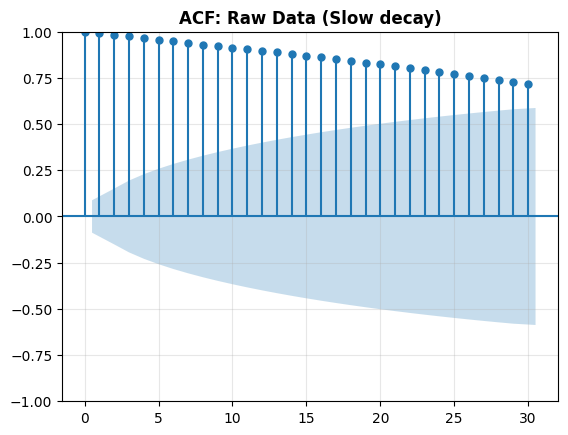

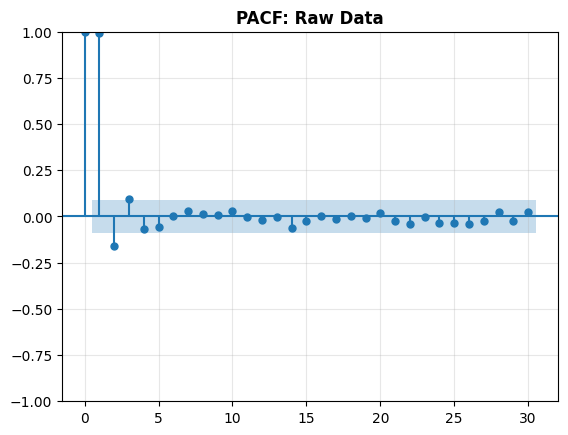

In [12]:
#checking the data for stationary
#from line graph we can see clear trend
#statioanrity checks can be done using the acf and pacf plots

#raw acf
plot_acf(df['daily price'], lags=30)
plt.title('ACF: Raw Data (Slow decay)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#raw pacf
plot_pacf(df['daily price'], lags=30)
plt.title('PACF: Raw Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

clearly the data is unstationary our model arma assumes the data to be stationary, so we have to make the data stationary, we can do that by differencing the price column, we will create new column for our differenced price data

In [13]:
#creating differenced col
df['price_diff'] = df['daily price'].diff()

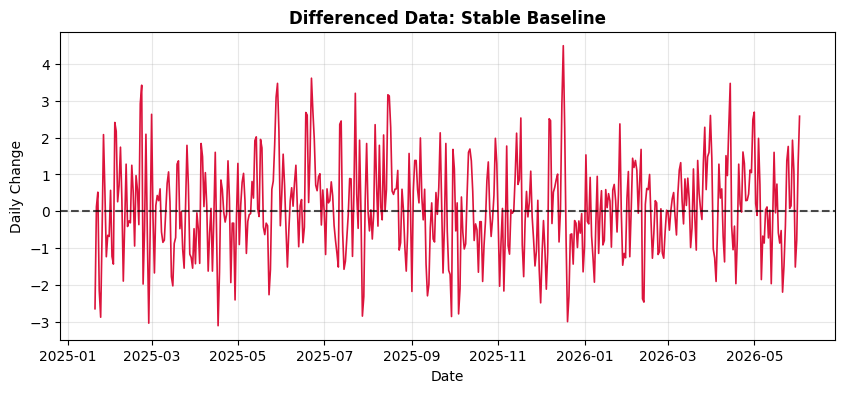

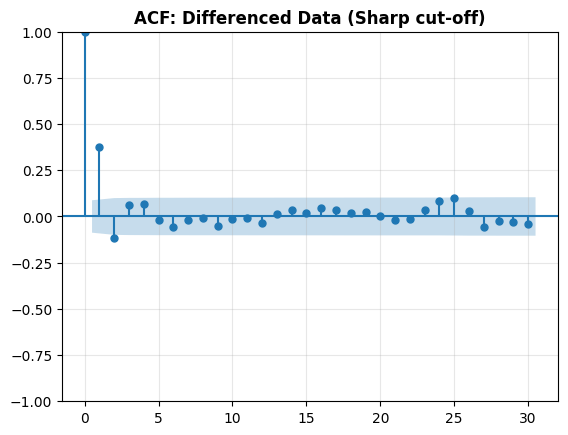

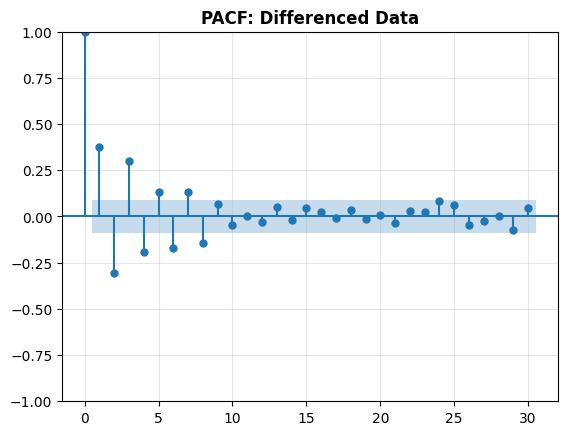

In [14]:
#differenced data lineplot

#remove nan values caused by differencing

diff_clean = df['price_diff'].dropna()

#differenced line

plt.figure(figsize=(10, 4))
plt.plot(diff_clean.index, diff_clean, color='crimson', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)  # Baseline at zero change
plt.title('Differenced Data: Stable Baseline', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Change')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data acf
plot_acf(diff_clean, lags=30)
plt.title('ACF: Differenced Data (Sharp cut-off)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data pacf

plot_pacf(diff_clean, lags=30)
plt.title('PACF: Differenced Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

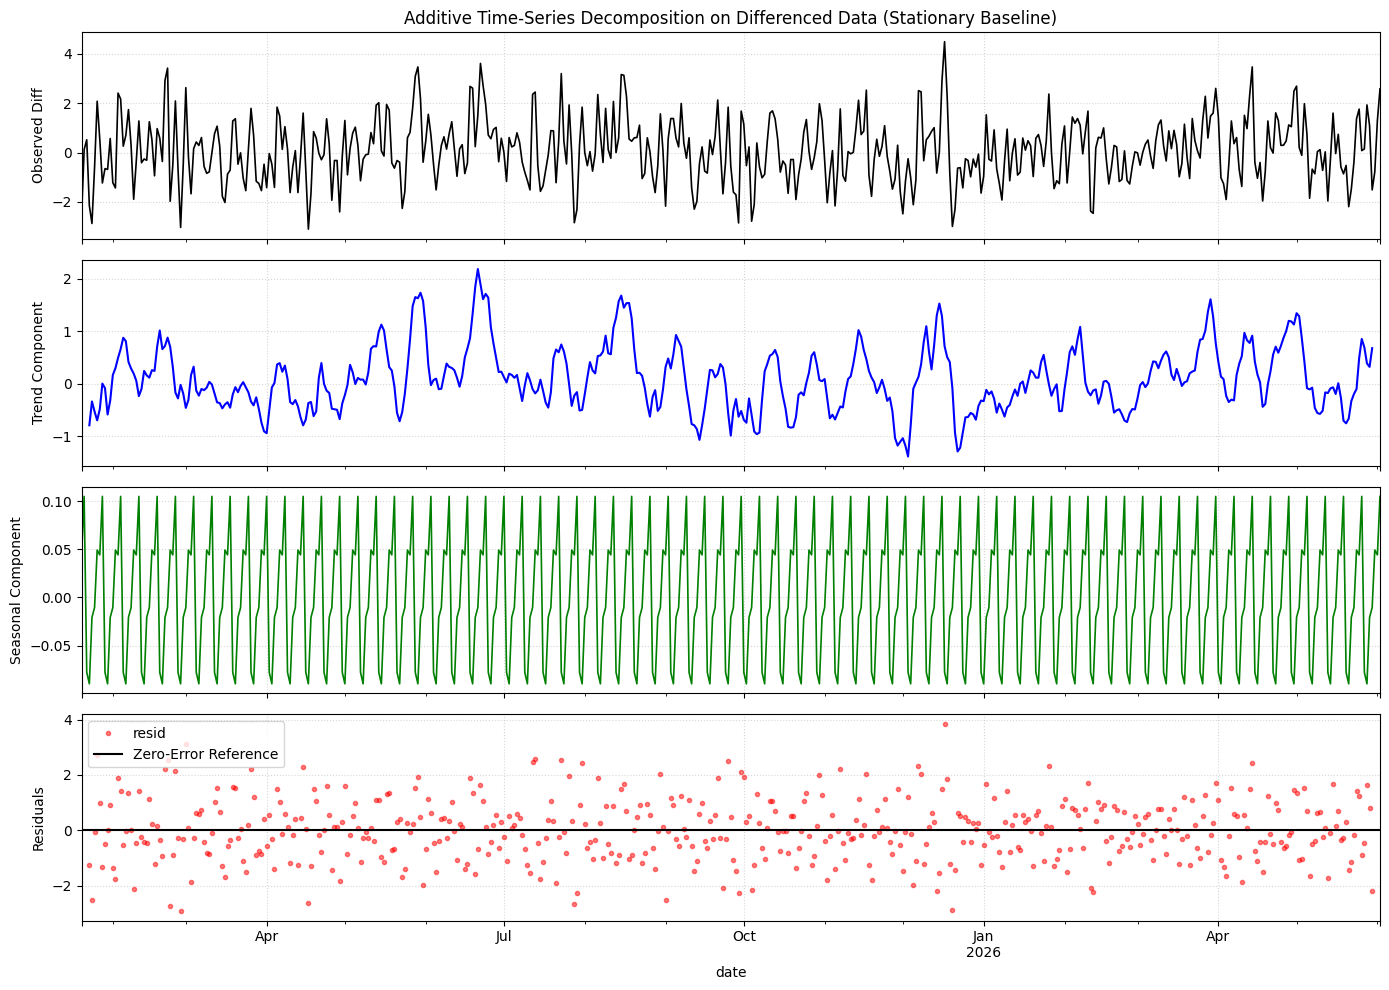

In [15]:
#first order differencing on the data


df_diff = df[['daily price']].diff().dropna()

#decompose differenced data for weekly cycles
decomposition_diff = seasonal_decompose(df_diff['daily price'], model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition_diff.observed.plot(ax=ax1, color='black', lw=1.2)
ax1.set_ylabel('Observed Diff')
ax1.set_title('Additive Time-Series Decomposition on Differenced Data (Stationary Baseline)')
ax1.grid(True, linestyle=':', alpha=0.5)

#Trend component
decomposition_diff.trend.plot(ax=ax2, color='blue', lw=1.5)
ax2.set_ylabel('Trend Component')
ax2.grid(True, linestyle=':', alpha=0.5)

#Seasonal component
decomposition_diff.seasonal.plot(ax=ax3, color='green', lw=1.2)
ax3.set_ylabel('Seasonal Component')
ax3.grid(True, linestyle=':', alpha=0.5)

#Residuals of Differenced Series
decomposition_diff.resid.plot(ax=ax4, color='red', style='.', alpha=0.5)
ax4.axhline(y=0, color='black', linestyle='-', lw=1.5, label='Zero-Error Reference')
ax4.set_ylabel('Residuals')
ax4.grid(True, linestyle=':', alpha=0.5)
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

defining models, is the one we are looking at now, arma takes the stationary data, it cant perform on non stationary data, as we will be required to give it the stationary data
the parameter d will be 1 which stands for the data has been differenced once

while arima is a manual model, it can perform on raw data meaning, we can define its parameters (p,d,q) which we are required to do so and as we give the parmeters to loop on the model picks the best differenced data in our case could be 0,1,2 0 stands for raw data, mostly I am assuming model is going to pick d =2 even if we have found the stationarity at d=1(differencing one time)

In [16]:
#time series train and test split

#80 train 20 test
split_idx = int(len(df) * 0.80)

train_data = df.iloc[:split_idx]
test_data = df.iloc[split_idx:]

print(f"Total Observations: {len(df)} days")
print(f"Training Set Range: {train_data.index.min().strftime('%Y-%m-%d')} to {train_data.index.max().strftime('%Y-%m-%d')} ({len(train_data)} days)")
print(f"Holdout Test Range: {test_data.index.min().strftime('%Y-%m-%d')} to {test_data.index.max().strftime('%Y-%m-%d')} ({len(test_data)} days)")

Total Observations: 500 days
Training Set Range: 2025-01-19 to 2026-02-22 (400 days)
Holdout Test Range: 2026-02-23 to 2026-06-02 (100 days)


In [17]:
y_train = train_data['daily price']
y_test  = test_data['daily price']


so, as we have already split our data, so we have 2 trends in this data which has stochastic and deterministic trend, so whhat happens
is that if have d=1 the model may remove the stochastic trend but may not remove the deterministic trend, so what we can do is cross compare 3 models which are arima(normal where mostly model picks d=1), then we pick the best model where arima(d=2) and also we can introduce the trend component which will be arima+trend and we will compare 3 of them visually on the test set and pick the best model.

In [18]:
def arima_grid_search(train_series, test_series, 
                      p_range=range(0, 9), 
                      d_range=range(0, 3), 
                      q_range=range(0, 9)):

    best_aic = float("inf")
    best_rmse = float("inf")
    best_order = None
    best_model = None

    print("Running ARIMA grid search...")

    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train_series, order=(p, d, q)).fit()

                    forecast = model.forecast(steps=len(test_series))
                    rmse = np.sqrt(mean_squared_error(test_series, forecast))

                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_rmse = rmse
                        best_order = (p, d, q)
                        best_model = model

                    print(f"ARIMA{(p,d,q)}  AIC={model.aic:.2f}  RMSE={rmse:.4f}")

                except:
                    continue

    print("\nBest Model Found:")
    print(f"Order: {best_order}")
    print(f"AIC: {best_aic:.2f}")
    print(f"RMSE on Test Set: {best_rmse:.4f}")

    return {
        "best_order": best_order,
        "best_model": best_model,
        "best_aic": best_aic,
        "best_rmse": best_rmse
    }


results = arima_grid_search(
    train_data['daily price'],
    test_data['daily price']
)

best_model = results["best_model"]
best_order = results["best_order"]


Running ARIMA grid search...
ARIMA(0, 0, 0)  AIC=3360.72  RMSE=19.0079


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-pric

ARIMA(0, 0, 1)  AIC=2821.87  RMSE=19.0161


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(0, 0, 2)  AIC=2325.29  RMSE=19.0083


...

c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(8, 2, 6)  AIC=1153.45  RMSE=12.6143


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(8, 2, 7)  AIC=1156.20  RMSE=13.1480
ARIMA(8, 2, 8)  AIC=1166.11  RMSE=12.6099

Best Model Found:
Order: (5, 1, 4)
AIC: 1145.73
RMSE on Test Set: 15.2698


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
def arima_d2_grid_search(train_series, test_series, 
                         p_range=range(0, 9), 
                         q_range=range(0, 9)):


    best_aic = float("inf")
    best_rmse = float("inf")
    best_order = None
    best_model = None

    print("Running ARIMA grid search for d=2...")

    for p in p_range:
        for q in q_range:
            try:
                model = ARIMA(train_series, order=(p, 2, q)).fit()

                forecast = model.forecast(steps=len(test_series))
                rmse = np.sqrt(mean_squared_error(test_series, forecast))

                if model.aic < best_aic:
                    best_aic = model.aic
                    best_rmse = rmse
                    best_order = (p, 2, q)
                    best_model = model

            except:
                continue

    print("\nBest d=2 Model Found:")
    print(f"Order: {best_order}")
    print(f"AIC: {best_aic:.2f}")
    print(f"RMSE on Test Set: {best_rmse:.4f}")

    return {
        "best_order": best_order,
        "best_model": best_model,
        "best_aic": best_aic,
        "best_rmse": best_rmse
    }

results_d2 = arima_d2_grid_search(
    train_data['daily price'],
    test_data['daily price']
)

best_model_d2 = results_d2["best_model"]
best_order_d2 = results_d2["best_order"]


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-pric

Running ARIMA grid search for d=2...


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-pric


Best d=2 Model Found:
Order: (7, 2, 7)
AIC: 1146.38
RMSE on Test Set: 12.6210


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
#arima+trend
def arima_trend_grid_search(train_series, test_series, 
                            p_range=range(0, 9), 
                            d_range=range(0, 3), 
                            q_range=range(0, 9)):

    best_aic = float("inf")
    best_rmse = float("inf")
    best_order = None
    best_model = None

    print("Running ARIMA grid search WITH trend='t' ...")

    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train_series, order=(p, d, q), trend='t').fit()

                    forecast = model.forecast(steps=len(test_series))
                    rmse = np.sqrt(mean_squared_error(test_series, forecast))

                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_rmse = rmse
                        best_order = (p, d, q)
                        best_model = model

                    print(f"ARIMA{(p,d,q)} + trend  AIC={model.aic:.2f}  RMSE={rmse:.4f}")

                except:
                    continue

    print("\nBest Trend Model Found:")
    print(f"Order: {best_order}")
    print(f"AIC: {best_aic:.2f}")
    print(f"RMSE on Test Set: {best_rmse:.4f}")

    return {
        "best_order": best_order,
        "best_model": best_model,
        "best_aic": best_aic,
        "best_rmse": best_rmse
    }

trend_results = arima_trend_grid_search(
    train_data['daily price'],
    test_data['daily price']
)

best_model_trend = trend_results["best_model"]
best_order_trend = trend_results["best_order"]


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-pric

Running ARIMA grid search WITH trend='t' ...
ARIMA(0, 0, 0) + trend  AIC=3551.09  RMSE=33.1300
ARIMA(0, 0, 1) + trend  AIC=3013.46  RMSE=32.8557


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(0, 0, 2) + trend  AIC=2507.66  RMSE=32.6253


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


...

c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(8, 1, 6) + trend  AIC=1156.85  RMSE=12.9336


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(8, 1, 7) + trend  AIC=1152.99  RMSE=14.3026
ARIMA(8, 1, 8) + trend  AIC=1156.71  RMSE=12.3633

Best Trend Model Found:
Order: (3, 1, 7)
AIC: 1147.18
RMSE on Test Set: 12.5764


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDr

c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDr

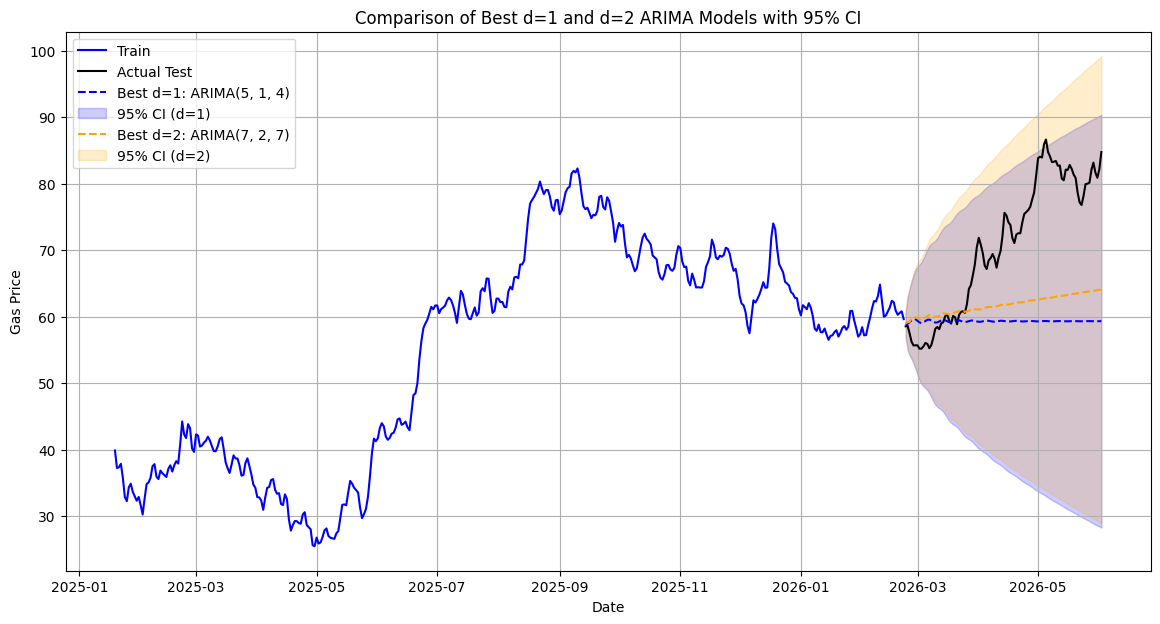

In [21]:
def plot_arima_d1_d2_comparison(
    train_series, 
    test_series, 
    order_d1=(5,1,4), 
    order_d2=(7,2,7)
):

    # Fit models
    model_d1 = ARIMA(train_series, order=order_d1).fit()
    model_d2 = ARIMA(train_series, order=order_d2).fit()

    # Forecast
    fc_d1 = model_d1.get_forecast(steps=len(test_series))
    fc_d2 = model_d2.get_forecast(steps=len(test_series))

    d1_mean = fc_d1.predicted_mean
    d1_ci = fc_d1.conf_int()

    d2_mean = fc_d2.predicted_mean
    d2_ci = fc_d2.conf_int()

    # Plot
    plt.figure(figsize=(14,7))

    # Train
    plt.plot(train_series.index, train_series, label="Train", color="blue")

    # Test
    plt.plot(test_series.index, test_series, label="Actual Test", color="black")

    # d=1 forecast
    plt.plot(test_series.index, d1_mean, 
             label=f"Best d=1: ARIMA{order_d1}", 
             linestyle="--", color="blue")
    plt.fill_between(
        test_series.index,
        d1_ci.iloc[:,0],
        d1_ci.iloc[:,1],
        color="blue",
        alpha=0.2,
        label="95% CI (d=1)"
    )

    # d=2 forecast
    plt.plot(test_series.index, d2_mean, 
             label=f"Best d=2: ARIMA{order_d2}", 
             linestyle="--", color="orange")
    plt.fill_between(
        test_series.index,
        d2_ci.iloc[:,0],
        d2_ci.iloc[:,1],
        color="orange",
        alpha=0.2,
        label="95% CI (d=2)"
    )

    plt.title("Comparison of Best d=1 and d=2 ARIMA Models with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_arima_d1_d2_comparison(
    y_train, 
    y_test, 
    order_d1=(5,1,4), 
    order_d2=(7,2,7)
)


as our model d=2 (7,2,7) is the winner now we will compare that with our trend plot to confirm which is our best model

c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sagal\OneDr

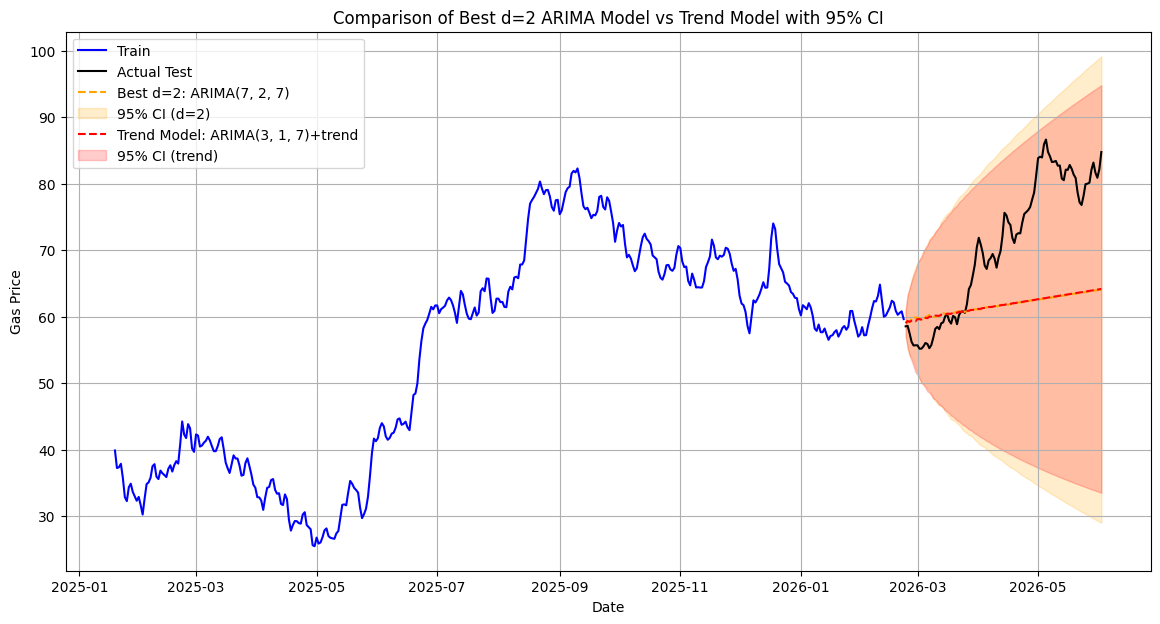

In [22]:
def plot_arima_d2_vs_trend(
    train_series,
    test_series,
    order_d2=(7,2,7),
    order_trend=(3,1,7)
):
 
    # Fit models
    model_d2 = ARIMA(train_series, order=order_d2).fit()
    model_trend = ARIMA(train_series, order=order_trend, trend='t').fit()

    # Forecast
    fc_d2 = model_d2.get_forecast(steps=len(test_series))
    fc_trend = model_trend.get_forecast(steps=len(test_series))

    d2_mean = fc_d2.predicted_mean
    d2_ci = fc_d2.conf_int()

    trend_mean = fc_trend.predicted_mean
    trend_ci = fc_trend.conf_int()

    # Plot
    plt.figure(figsize=(14,7))

    # Train
    plt.plot(train_series.index, train_series, label="Train", color="blue")

    # Test
    plt.plot(test_series.index, test_series, label="Actual Test", color="black")

    # d=2 forecast
    plt.plot(test_series.index, d2_mean,
             label=f"Best d=2: ARIMA{order_d2}",
             linestyle="--", color="orange")
    plt.fill_between(
        test_series.index,
        d2_ci.iloc[:,0].values,
        d2_ci.iloc[:,1].values,
        color="orange",
        alpha=0.2,
        label="95% CI (d=2)"
    )

    # Trend model forecast
    plt.plot(test_series.index, trend_mean,
             label=f"Trend Model: ARIMA{order_trend}+trend",
             linestyle="--", color="red")
    plt.fill_between(
        test_series.index,
        trend_ci.iloc[:,0].values,
        trend_ci.iloc[:,1].values,
        color="red",
        alpha=0.2,
        label="95% CI (trend)"
    )

    plt.title("Comparison of Best d=2 ARIMA Model vs Trend Model with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_arima_d2_vs_trend(
    y_train,
    y_test,
    order_d2=(7,2,7),
    order_trend=(3,1,7)
)


We compared the best d=2 ARIMA model with the best trend-augmented ARIMA model using both AIC and RMSE:

ARIMA(7,2,7)
AIC = 1146.38
RMSE = 12.6210

ARIMA(3,1,7) + trend='t'  
AIC = 1147.18
RMSE = 12.5764


trend model achieves a lower RMSE, meaning it predicts the test data more accurately.  
AIC difference is only 0.80, which is less than the threshold of 2 
therefore, AIC does not provide a statistically significant advantage to the d=2 model.  
The trend model is also more stable and interpretable, as it explicitly captures the deterministic trend rather than relying on second differencing.

Although ARIMA(7,2,7) has a slightly lower AIC, the difference is negligible.  
Given its better RMSE, greater stability, and theoretical justification, the  
ARIMA(3,1,7) + trend='t' model is selected as the final model for forecasting.


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


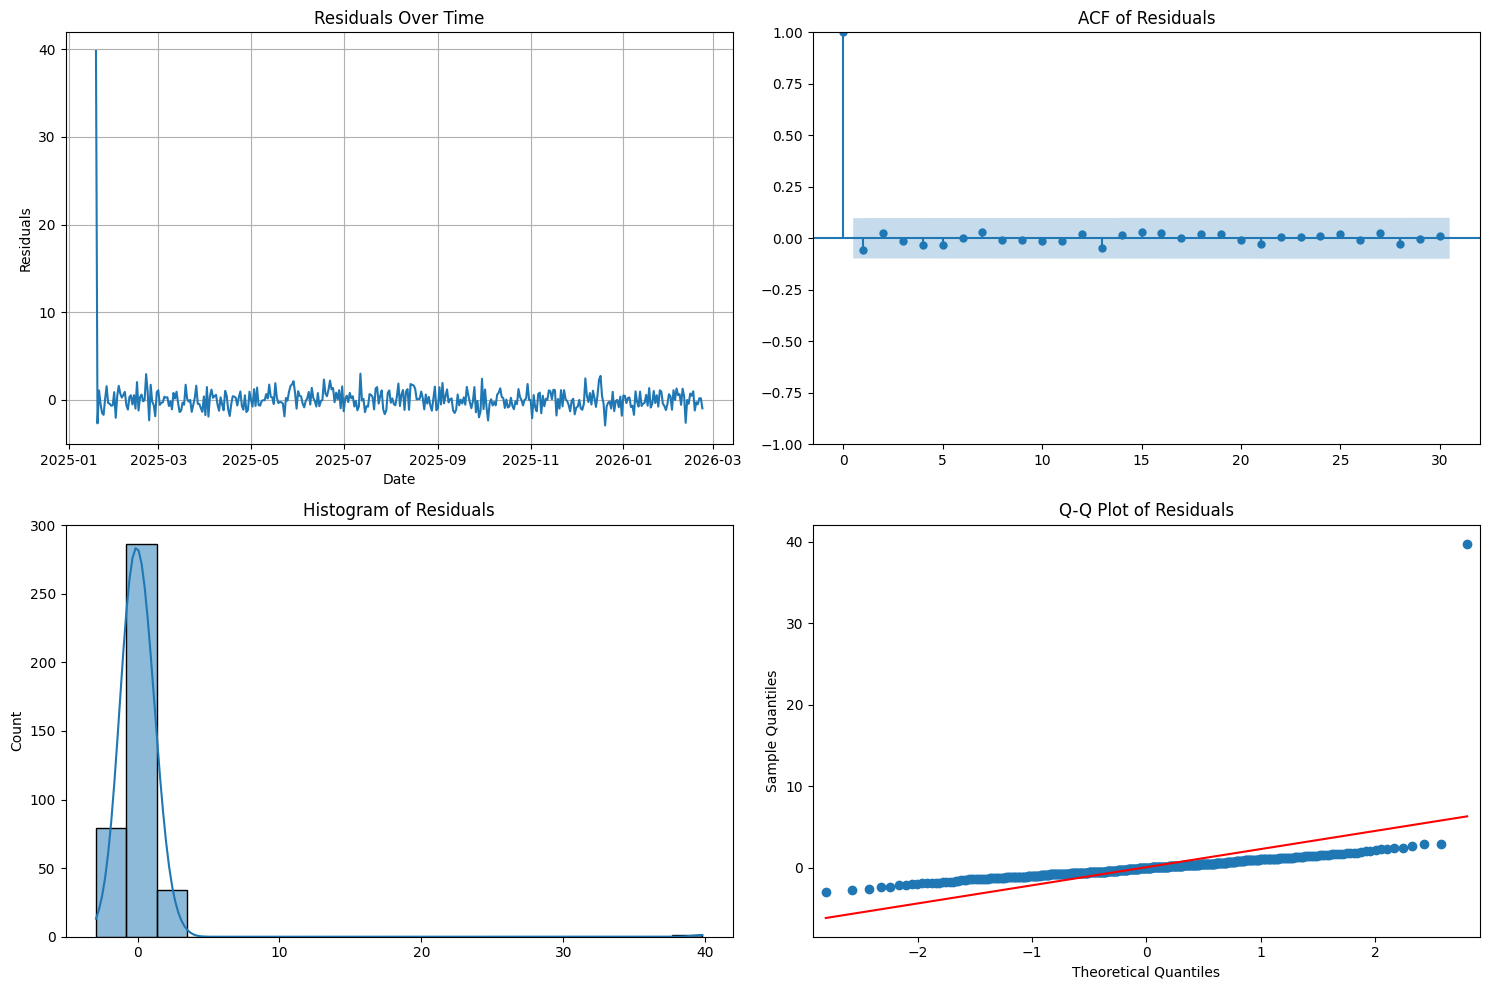

Ljung-Box Test Results:
     lb_stat  lb_pvalue
10  2.940000   0.982801
20  5.107225   0.999673
30  6.432568   0.999998


In [23]:
#fit final model on full data
final_model = ARIMA(y_train, order=(3,1,7), trend='t').fit()

#residuals
residuals = final_model.resid

plt.figure(figsize=(15,10))

#residual time series
plt.subplot(2,2,1)
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid(True)

#acf
plt.subplot(2,2,2)
plot_acf(residuals, ax=plt.gca(), lags=30)
plt.title("ACF of Residuals")

#histogram of residuals
plt.subplot(2,2,3)
sns.histplot(residuals, kde=True, bins=20)
plt.title("Histogram of Residuals")

#QQ plots
plt.subplot(2,2,4)
qqplot(residuals, line='s', ax=plt.gca())
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

#Ljung box
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test Results:")
print(lb_test)


In [24]:
print(y.index)


NameError: name 'y' is not defined

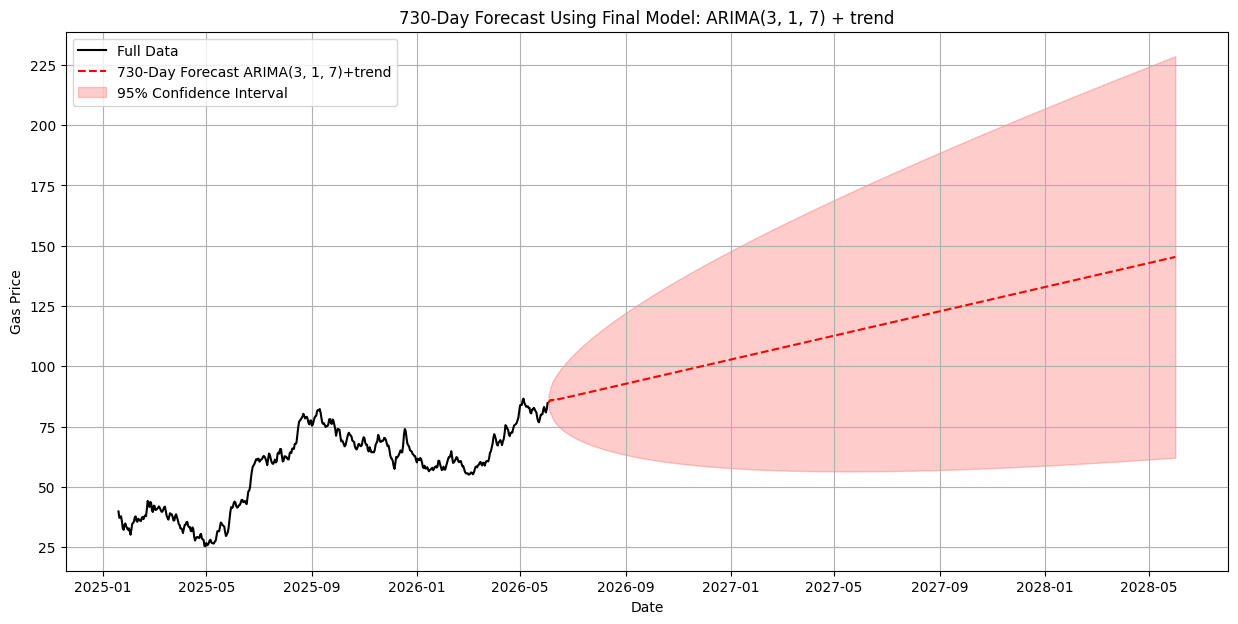

In [ ]:
def plot_final_arima_forecast(
    full_series,
    order=(3,1,7),
    forecast_days=730
):

    # Fit final model
    model = ARIMA(full_series, order=order, trend='t').fit()

    # Forecast
    fc = model.get_forecast(steps=forecast_days)
    fc_mean = fc.predicted_mean
    fc_ci = fc.conf_int()

    # Daily future index
    future_index = pd.date_range(
        start=full_series.index[-1] + pd.Timedelta(days=1),
        periods=forecast_days,
        freq='D'
    )

    # Plot
    plt.figure(figsize=(15,7))

    plt.plot(full_series.index, full_series, 
             label="Full Data", color="black")

    plt.plot(future_index, fc_mean,
             label=f"{forecast_days}-Day Forecast ARIMA{order}+trend",
             linestyle="--", color="red")

    plt.fill_between(
        future_index,
        fc_ci.iloc[:,0].values,
        fc_ci.iloc[:,1].values,
        color="red",
        alpha=0.2,
        label="95% Confidence Interval"
    )

    plt.title(f"{forecast_days}-Day Forecast Using Final Model: ARIMA{order} + trend")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, fc_mean, fc_ci, future_index

y = df['daily price']

final_model, fc_mean, fc_ci, future_index = plot_final_arima_forecast(
    y,
    order=(3,1,7),
    forecast_days=730
)



In [32]:
# Extract values from grid search results
best_order_trend = trend_results["best_order"]
best_model_trend = trend_results["best_model"]
best_aic_trend = trend_results["best_aic"]
best_rmse_trend = trend_results["best_rmse"]

# Save metrics
import json

arima_trend_metrics = {
    "model": f"ARIMA{best_order_trend}+trend",
    "aic": best_aic_trend,
    "rmse": best_rmse_trend
}

with open("../model_outputs/arima_trend_metrics.json", "w") as f:
    json.dump(arima_trend_metrics, f, indent=4)
